# Uue reegli testimine

See notebook on mõeldud uue reegli kiireks proovimiseks koondkorpuse valimil.


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import os

from estnltk.storage.postgres import PostgresStorage

from rule_based_ner_correction.testimine import run_rule_analysis_on_items, compare_change_rows
from rule_based_ner_correction.boundary.base import BaseRule, RuleProposal
from rule_based_ner_correction.missing.base import BaseMissingRule, MissingProposal
from rule_based_ner_correction.visualizer import draw_tree

In [3]:
OUTPUT_DIR = Path('outputs/single_rule_tests')
MAX_TEXTS = 10000

BASE_LAYER = 'v171_named_entities'
OUTPUT_LAYER = 'single_rule_test'
MORPH_LAYER = 'morph_analysis'
SYNTAX_LAYER = 'v172_stanza_syntax'

LAYERS=['words', MORPH_LAYER, SYNTAX_LAYER, BASE_LAYER]

## Andmete sisselugemine koondkorpuse andmebaasist

In [4]:
def load_items(collection, max_texts=MAX_TEXTS):
    items = []
    for text_id, text in collection.select(layers=LAYERS):
        items.append((text_id, text))
        if max_texts is not None and len(items) >= max_texts:
            break
    return items

In [5]:
pgpass_file = 'pgpass.txt'
assert os.path.exists(pgpass_file)

storage = PostgresStorage(
    pgpass_file=pgpass_file,
    schema='estonian_text_corpora',
    role='estonian_text_corpora_read'
)

collection_name = 'koondkorpus_sentences_test_5000_sg_thread'
collection = storage[collection_name]

items = load_items(collection)
print(len(items))

storage.close()

INFO:storage.py:57: connecting to host: 'postgres.keeleressursid.ee', port: '5432', dbname: 'estonian-text-corpora', user: 'kaarelku'
INFO:storage.py:108: schema: 'estonian_text_corpora', temporary: False, role: 'estonian_text_corpora_read'
10000


## Reegli toorik

Olemasolevat nimeüksust muutev reegel on `BaseRule` alamklass. Puuduvat nimeüksust lisav reegel on `BaseMissingRule` alamklass.

`BaseRule` puhul määra vajadusel klassile ka `stage`, kui reegel peab jooksma kindlas faasis:

- `split`
- `adjust`
- `finalize`

Kui `stage` jätta määramata, kasutatakse vaikimisi väärtust `adjust`.


In [6]:
class MyTestRule(BaseRule):
    rule_id = 'minu_testireegel'
    description = 'Notebookis kirjutatud katsetusreegel.'
    stage = 'adjust'

    def applies_to(self, span, context):
        return span.label == 'PER'

    def propose(self, span, context):
        next_token = context.next_token(span)
        if next_token is None:
            return None
        if next_token.text not in {'Palu'}:
            return None

        new_span = context.span_from_indices(span.label, span.start_i, span.end_i + 1)
        return RuleProposal(
            rule_id=self.rule_id,
            operation='replace',
            score=0.99,
            spans=[new_span],
        )


rule = MyTestRule()


## Testimine

In [7]:
result = run_rule_analysis_on_items(
    items=items,
    rule=rule,
    output_dir=OUTPUT_DIR,
    base_layer=BASE_LAYER,
    output_layer=OUTPUT_LAYER,
    morph_layer=MORPH_LAYER,
    syntax_layer=SYNTAX_LAYER,
)

change_rows = result['change_rows']
proposal_rows = result['proposal_rows']
corrected_items = result['corrected_items']

result['paths']['change_rows']

100%|██████████| 10000/10000 [00:24<00:00, 412.89it/s]


WindowsPath('outputs/single_rule_tests/minu_testireegel_change_rows.csv')

### Tulemus

In [8]:
change_rows[:20]

,text_id,change_type,base_count,new_count,base_texts,new_texts,base_labels,new_labels,base_lemmas,new_lemmas,...,base_external_head_texts,new_external_head_texts,base_external_head_deprels,new_external_head_deprels,base_external_head_morph_pos,new_external_head_morph_pos,anchor_window_text,text,source_stage,source_rule
0,539,EXPANDED,1,1,[[Peeter]],[Peeter Palu],[PER],[PER],[[Peeter]],"[[Peeter, paluma]]",...,[[esimees]],[[esimees]],[[root]],[[root]],[[S]],[[S]],” Otsustamise ajal oli Peeter Palu Saarte Liinide juhatuse esimees,” ” Otsustamise ajal oli Peeter Palu Saarte Liinide juhatuse esimees .,boundary,minu_testireegel


### Kahe change_rows faili võrdlus


In [9]:
OLD_CHANGE_ROWS = OUTPUT_DIR / 'minu_testireegel_change_rows_vana.csv'
NEW_CHANGE_ROWS = OUTPUT_DIR / 'minu_testireegel_change_rows.csv'

comparison = compare_change_rows(OLD_CHANGE_ROWS, NEW_CHANGE_ROWS)
comparison['summary']


,category,count
0,added,0
1,removed,1
2,changed,0


In [10]:
comparison['added'].head(30)


""


In [11]:
comparison['removed'].head(30)


,text_id,change_type,base_count,new_count,base_texts,new_texts,base_labels,new_labels,base_lemmas,new_lemmas,...,base_internal_root_morph_pos,new_internal_root_morph_pos,base_external_head_texts,new_external_head_texts,base_external_head_deprels,new_external_head_deprels,base_external_head_morph_pos,new_external_head_morph_pos,anchor_window_text,text
0,5173,EXPANDED,1,1,"[(Kaarel, Lauk)]",[Kaarel Lauk palus],[PER],[PER],"[(Kaarel, Lauk)]","[(Kaarel, Lauk, paluma)]",...,"[(H,)]","[(H, V)]","[(vallavanem,)]","[(vallavanem,)]","[(nsubj,)]","[(nsubj,)]","[(S,)]","[(S,)]",Ruhnu vallavanem Kaarel Lauk palus Saare maakonna valimiskomisjonil ümber,Ruhnu vallavanem Kaarel Lauk palus Saare maakonna valimiskomisjonil ümber vaadata Ruhnu valla valimiskomisjoni asendusliikmete registreerimise otsuse .


In [12]:
comparison['changed'].head(30)


""


### Süntaksipuud

Text (539): ” ” Otsustamise ajal oli Peeter Palu Saarte Liinide juhatuse esimees .


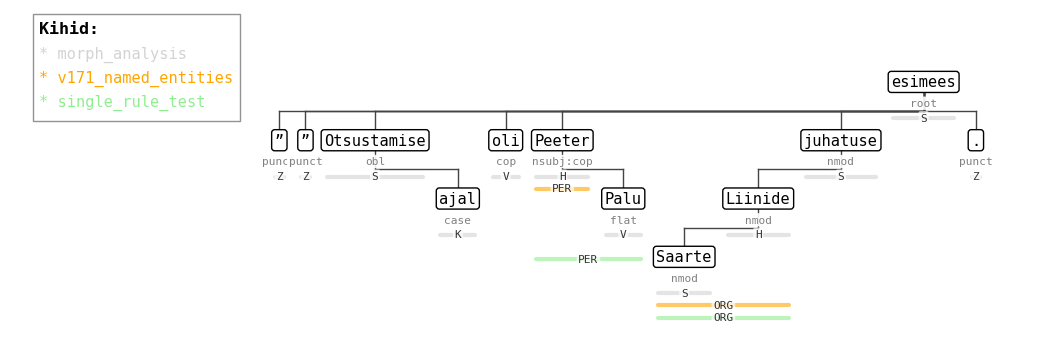

In [13]:
text_ids = list(change_rows['text_id'])[:5]

for id, text in corrected_items:
    if id in text_ids:
        print(f'Text ({id}): {text.text}')
        draw_tree(
            text, 
            syntax_layer=SYNTAX_LAYER, 
            spans=[
                {'name': MORPH_LAYER, 'color': 'lightgrey', 'label': 'partofspeech'},
                {'name': BASE_LAYER, 'color': 'orange', 'label': 'nertag'},
                {'name': OUTPUT_LAYER, 'color': 'lightgreen', 'label': 'nertag'},
            ]
)



## Taggeri katsetus

Siin all on näide, kuidas anda taggerile kõik reeglid ühe listina.


In [14]:
from rule_based_ner_correction import RuleBasedNerCorrectionTagger, get_default_rules

from estnltk import Text
from estnltk.taggers import NerTagger
from estnltk_neural.taggers import StanzaSyntaxTagger

syntax_t = StanzaSyntaxTagger()
ner_t = NerTagger()

tagger_rules = get_default_rules() + [MyTestRule()]

tagger = RuleBasedNerCorrectionTagger(
    ner_layer="ner",
    morph_layer="morph_analysis",
    syntax_layer="stanza_syntax",
    output_layer="ner_corrected",
    rules=tagger_rules,
)


In [15]:
test = Text('Volkswageni autode esindaja AS Saksa Auto avas oktoobri lõpul Tallinnas Mustamäe teel uue müügi- ja teeninduskeskuse .')

test.tag_layer('morph_analysis')
syntax_t.tag(test)
ner_t.tag(test)
tagger.tag(test)

Text(text='Volkswageni autode esindaja AS Saksa Auto avas oktoobri lõpul Tallinnas Mustamäe teel uue müügi- ja teeninduskeskuse .')

In [16]:
test.ner_corrected

Layer(name='ner_corrected', attributes=('nertag',), spans=SL[Span('AS Saksa Auto', [{'nertag': 'ORG'}]),
Span('Tallinnas', [{'nertag': 'LOC'}]),
Span('Mustamäe teel', [{'nertag': 'LOC'}])])

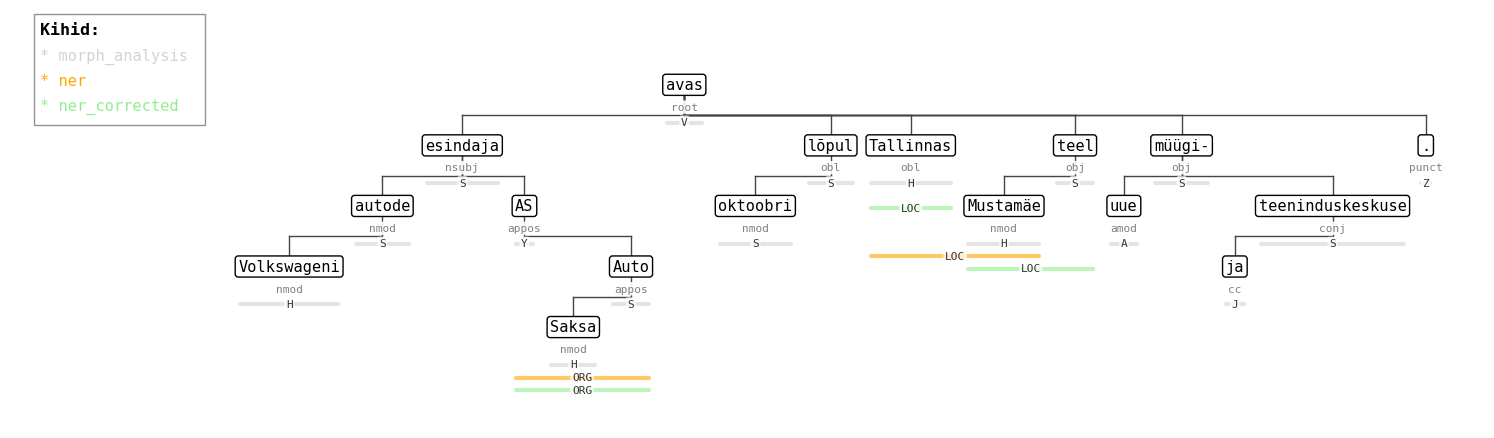

<Axes: >

In [17]:
draw_tree(
    test, 
    syntax_layer="stanza_syntax", 
    spans=[
        {'name': "morph_analysis", 'color': 'lightgrey', 'label': 'partofspeech'},
        {'name': "ner", 'color': 'orange', 'label': 'nertag'},
        {'name': "ner_corrected", 'color': 'lightgreen', 'label': 'nertag'},
    ]
)